In [86]:
# ===== 1) IMPORTS & GLOBAL CONFIG =====
from __future__ import annotations

import re
import time
import pandas as pd
from bs4 import BeautifulSoup

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# ---- What to scrape (edit these) ----
SCHOOLS = {
    # Use {year} in each URL; keep ?view=2 for the table/grid view when available.
    "Jackson State": "https://gojsutigers.com/sports/football/roster/{year}?view=2",
    "Alabama State": "https://bamastatesports.com/sports/football/roster/{year}?view=2",
    "Alabama A&M": "https://aamusports.com/sports/football/roster/{year}?view=2",
    "Southern": "https://gojagsports.com/sports/football/roster/{year}?view=2",
    "Prairie View A&M": "https://pvpanthers.com/sports/football/roster/{year}?view=2",
    "Texas Southern": "https://tsusports.com/sports/football/roster/{year}?view=2",
    "UAPB": "https://uapblionsroar.com/sports/football/roster/{year}?view=2",
    "Alcorn State": "https://alcornsports.com/sports/football/roster/{year}?view=2",
    "Grambling": "https://gsutigers.com/sports/football/roster/{year}?view=2",
    "Mississippi Valley State": "https://mvsusports.com/sports/football/roster/{year}?view=2",
    "Florida A&M": "https://famuathletics.com/sports/football/roster/{year}?view=2",
    "Bethune-Cookman": "https://bcuathletics.com/sports/football/roster/{year}?view=2"

}

YEARS = list(range(2010, 2026))     # inclusive range you want to scrape
HEADLESS = True                     # set False to watch the browser work
PAGE_LOAD_TIMEOUT = 20              # seconds to wait for page/table
POLITE_DELAY = 1.5                  # seconds between requests (be nice)
EMPTY_ROW_THRESHOLD = 1              # 0–1 row = “empty”
AUTO_STOP_CONSECUTIVE = 4            # stop after 4 empty years in a row

In [87]:
# ===== 2) SELENIUM DRIVER FACTORY =====
def make_driver(headless: bool = True): # -> webdriver.Chrome:
    opts = Options() # browser options
    if headless: # run in headless mode (no GUI)
        opts.add_argument("--headless=new") # updated for Chrome 109+
    opts.add_argument("--no-sandbox") # required when running as root user. otherwise you would get no sandbox errors
    opts.add_argument("--disable-dev-shm-usage") # overcome limited resource problems
    opts.add_argument("--window-size=1920,1080") # set window size to avoid potential issues
    # Selenium Manager will fetch the right ChromeDriver automatically.
    driver = webdriver.Chrome(options=opts) # start the browser
    driver.set_page_load_timeout(PAGE_LOAD_TIMEOUT) # set timeout
    return driver # return the driver


In [88]:
# ===== 3) SCRAPER (ONE PAGE) =====
def scrape_roster_table(driver, url: str) -> pd.DataFrame | None:
    """
    Load a Sidearm roster ?view=2 table and return a DataFrame or None.
    Includes redirect detection + timeout guard to prevent hanging on bad pages.
    """
    try:
        # --- Load page safely with timeout guard ---
        driver.set_page_load_timeout(PAGE_LOAD_TIMEOUT)
        driver.get(url)

        # --- Detect redirect (keep right here, immediately after driver.get) ---
        final_url = driver.current_url
        if final_url.rstrip("/") != url.rstrip("/"):
            import re
            year_in_url = re.search(r"/(\d{4})", url)
            year_in_final = re.search(r"/(\d{4})", final_url)
            # Only skip if the redirect changed the year (e.g., 2021 → 2025)
            if not year_in_final or (year_in_url and year_in_url.group(1) != year_in_final.group(1)):
                print(f"[!] Redirected from {url} → {final_url}. Likely missing roster.")
                return None

    except Exception as e:
        print(f"[!] Timeout or load failure for {url} ({e})")
        return None

    # --- Wait for table to appear ---
    try:
        WebDriverWait(driver, PAGE_LOAD_TIMEOUT).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "table.sidearm-table"))
        )
    except Exception:
        time.sleep(0.75)
        print(f"[!] No roster table detected: {url}")
        return None

    # --- Parse the table using BeautifulSoup ---
    soup = BeautifulSoup(driver.page_source, "lxml")
    table = soup.find("table", class_="sidearm-table")
    if not table:
        return None

    thead = table.find("thead")
    headers = [th.get_text(strip=True) for th in thead.find_all("th")] if thead else []

    tbody = table.find("tbody")
    if not tbody:
        return None

    rows = []
    for tr in tbody.find_all("tr"):
        tds = tr.find_all("td")
        if not tds:
            continue
        rows.append([td.get_text(" ", strip=True) for td in tds])

    if not rows:
        return None

    try:
        df = pd.DataFrame(rows, columns=headers)
    except Exception as e:
        print(f"[!] DataFrame creation failed for {url} ({e})")
        return None

    return df

    ...




In [89]:
# ===== 4) NORMALIZATION HELPERS (robust + hometown fix) =====

# ---- 4.1 Header alias map (exact-ish fallbacks for common fields) ----
HEADER_MAP = {
    # names
    "full name": "name", "name": "name",

    # position
    "pos.": "pos", "position": "pos",

    # height / weight
    "ht.": "ht", "height": "ht",
    "wt.": "wt", "weight": "wt",

    # class / year
    "yr.": "yr", "year": "yr", "class": "yr", "class year": "yr",

    # number / jersey
    "#": "number", "no.": "number", "number": "number", "jersey": "number",

    # misc
    "image": "image",

    # IMPORTANT: if a column is literally "Hometown", map it to 'hometown'
    "hometown": "hometown",
}












In [ ]:
# ---- 4.2 Regex recognizers for messy/variant headers ----

# Plain "Hometown" (NOT followed by HS/Previous)
HOMETOWN_ONLY_RE = re.compile(
    r"\bhometown\b(?!.*\b(high\s*school|highschool|hs|prev|previous|last\s*school|transfer)\b)",
    re.I
)

# Any "Hometown + something" variants (high school / previous school / last school)
HOMETOWN_COMBINED_RE = re.compile(
    r"""
    \bhometown\b
    [\s/|–-]*                # flexible separators: space, slash, dash, pipe
    (                        # followed by:
        (high\s*school|highschool|hs)
        |(prev(iou)?s(\s*school)?s?)
        |(last(\s*school)?)
        |(transfer\s*from)
    )
    """,
    re.I | re.X
)

# Any "High School + Previous School" combined variants
HS_COMBINED_RE = re.compile(
    r"""
    \b(high\s*school|highschool|hs)\b
    [\s/|–-]*                  # slash, dash, or pipe
    (prev(iou)?s(\s*school)?s?|last\s*school|transfer\s*from)\b
    """,
    re.I | re.X
)

# Pure "High School" header
HS_ONLY_RE = re.compile(r"(?i)^(high\s*school|highschool|hs)$")

# Pure "Previous School" header
PREV_SCHOOL_RE = re.compile(
    r"(?i)^(prev(ious)?(\s*school)?s?|last\s*school|transfer\s*from)$"
)


In [ ]:
# Header Normalizer

def canonicalize_headers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map site-specific or messy headers to canonical names.
    Detects and cleans columns like:
      - 'Hometown / High School'
      - 'Hometown / Previous School'
      - 'High School / Previous School'
      - and standalone 'Hometown', 'High School', 'Previous School'
    """
    out = df.copy()
    mapped = []

    for col in out.columns:
        k = _norm_header_key(col)

        # --- Combo detections ---
        if HOMETOWN_COMBINED_RE.search(k):
            mapped.append("home_prev")  # e.g., 'Hometown / Previous School'
            continue
        if HS_COMBINED_RE.search(k):
            mapped.append("hs_prev")    # e.g., 'High School / Previous School'
            continue

        # --- Plain detections ---
        if HOMETOWN_ONLY_RE.search(k):
            mapped.append("hometown")
            continue
        if HS_ONLY_RE.search(k):
            mapped.append("high_school")
            continue
        if PREV_SCHOOL_RE.search(k):
            mapped.append("previous_schools")
            continue

        # --- Default to alias map or original ---
        mapped.append(HEADER_MAP.get(k, k))

    out.columns = mapped
    return out


In [ ]:
# ---- 4.4 Build a single reliable hometown output column (DUP-SAFE) ----
def finalize_hometown(df: pd.DataFrame, out_col: str = "hometown_std") -> pd.DataFrame:
    """
    Builds standardized 'hometown', 'high_school', and 'previous_schools' columns.
    Handles combined fields (e.g. 'Hometown / High School', 'Hometown / Previous School', 'HS / Prev School').
    """
    df = df.copy()

    # Utility: split combined fields into left/right
    def _split_pair(val: str):
        if not isinstance(val, str):
            return ("", "")
        parts = re.split(r"[\s/|–-]+", val.strip(), maxsplit=1)
        if len(parts) == 2:
            return (parts[0].strip(), parts[1].strip())
        return (parts[0].strip(), "")

    # Hometown base
    hometown, high_school, prev_school = pd.Series("", index=df.index), pd.Series("", index=df.index), pd.Series("", index=df.index)

    if "home_prev" in df.columns:
        pairs = df["home_prev"].apply(_split_pair)
        hometown, right_side = zip(*pairs)
        df["hometown"] = df.get("hometown", pd.Series(hometown))
        df["high_school"] = df.get("high_school", pd.Series(right_side))
        df["previous_schools"] = df.get("previous_schools", pd.Series(right_side))

    if "hs_prev" in df.columns:
        pairs = df["hs_prev"].apply(_split_pair)
        left_side, right_side = zip(*pairs)
        df["high_school"] = df.get("high_school", pd.Series(left_side))
        df["previous_schools"] = df.get("previous_schools", pd.Series(right_side))

    # Clean up whitespace
    for col in ["hometown", "high_school", "previous_schools"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        else:
            df[col] = pd.NA

    return df


In [93]:
# ---- 4.5 Convenience helper (optional) ----
def normalize_and_finalize(df: pd.DataFrame, out_col: str = "hometown") -> pd.DataFrame:
    """
    One-shot helper for the main loop:
      1) canonicalize headers (4.3)
      2) create 'hometown' column (4.4)
      3) enforce a consistent schema
    """
    df = canonicalize_headers(df)
    df = finalize_hometown(df, out_col=out_col)

    preferred_cols = [
        "number", "name", "pos", "ht", "wt", "yr",
        "hometown", "state", "high_school", "previous_schools",
    ]
    for c in preferred_cols:
        if c not in df.columns:
            df[c] = pd.NA

    return df[preferred_cols].copy()


In [102]:
# ===== 5) MAIN LOOP: DESC + AUTO-STOP =====
def scrape_schools_years_desc_autostop(schools: dict[str, str], years: list[int]) -> pd.DataFrame:
    """
    Scrape SIDEARM rosters for each school/year (newest -> oldest) with auto-stop.
    - Uses scrape_roster_table(driver, url) from Cell 3
    - Uses canonicalize_headers / finalize_hometown from Cell 4
    - Saves one CSV per school to `out_dir` (defined in RUN cell)
    Returns a concatenated DataFrame of all schools.
    """
    driver = make_driver(HEADLESS)
    all_frames: list[pd.DataFrame] = []

    try:
        for school, template in schools.items():
            print(f"\n=== {school} ===")
            school_frames: list[pd.DataFrame] = []
            consecutive_empty = 0

            for yr in sorted(years, reverse=True):  # newest → oldest
                url = template.format(year=yr)
                print(f"  Year {yr}: {url}")

                df = scrape_roster_table(driver, url)

                if df is None or df.shape[0] <= EMPTY_ROW_THRESHOLD:
                    consecutive_empty += 1
                    print(f"    -> Skipped (empty or <= {EMPTY_ROW_THRESHOLD} row). "
                          f"[{consecutive_empty} empty in a row]")
                else:
                    consecutive_empty = 0

                    # --- 1) Canonicalize headers (Cell 4)
                    base = canonicalize_headers(df)

                    # --- 2) Build reliable hometown (Cell 4)
                    base = finalize_hometown(base, out_col="hometown")

                    # --- 3) Enforce consistent schema
                    preferred_cols = [
                        "number", "name", "pos", "ht", "wt", "yr",
                        "hometown", "state", "high_school", "previous_schools",
                    ]
                    for c in preferred_cols:
                        if c not in base.columns:
                            base[c] = pd.NA

                    norm = base[preferred_cols].copy()

                    # --- 4) Add metadata & collect
                    norm.loc[:, "school"] = school
                    norm.loc[:, "year"] = yr
                    print(norm.columns.tolist())
                    print(norm.head(2).to_dict(orient="records"))
                    school_frames.append(norm)
                    print(f"    -> Got {norm.shape[0]} rows.")

                # Auto-stop after many empties in a row
                if consecutive_empty >= AUTO_STOP_CONSECUTIVE:
                    print(f"    -> Auto-stop for {school} "
                          f"(no real data last {AUTO_STOP_CONSECUTIVE} years).")
                    break

                time.sleep(POLITE_DELAY)  # be nice

            # Save per-school CSV (if any rows)
            if school_frames:  # if we got any data for this school
                # --- Fix duplicate column names before concatenation ---
                for i, df in enumerate(school_frames):
                    seen = {}
                    new_cols = []
                    for col in df.columns:
                        if col in seen:
                            seen[col] += 1
                            new_cols.append(f"{col}_{seen[col]}")
                        else:
                            seen[col] = 0
                            new_cols.append(col)
                    df.columns = new_cols
                    school_frames[i] = df

                # --- Combine all years for this school ---
                school_df = pd.concat(school_frames, ignore_index=True, sort=False)

                # --- Optional cleanup: remove duplicate or messy columns ---
                school_df.columns = (
                    school_df.columns.str.strip()
                    .str.lower()
                    .str.replace(r"\.+\d+$", "", regex=True)
                )
                school_df = school_df.loc[:, ~school_df.columns.duplicated()]

                # --- Save per-school CSV ---
                out_name = f"{school.replace(' ','_').replace('&','and').lower()}_rosters.csv"
                school_df.to_csv(os.path.join(out_dir, out_name), index=False)
                print(f"  Saved per-school CSV: {out_name}")

                # --- Add to master list ---
                all_frames.append(school_df)

            else:
                print("  (No rows for this school.)")


    finally:
        driver.quit()

    if not all_frames:
        print("[!] Nothing scraped — check URLs and years.")
        return pd.DataFrame()

    return pd.concat(all_frames, ignore_index=True, sort=False)




In [103]:
# ===== 6) RUN =====
import os

# Absolute folder path for all outputs
out_dir = r"C:\Users\jland\OneDrive\Emory Essentials\Research\College Football Output\SWAC Rosters"
os.makedirs(out_dir, exist_ok=True)   # ensures the folder exists

master_df = scrape_schools_years_desc_autostop(SCHOOLS, YEARS)

print("\n-- SUMMARY ---")
print(master_df.shape)
if not master_df.empty:
    print(master_df.groupby(["school", "year"]).size().sort_index())
    master_df.to_csv(os.path.join(out_dir, "all_rosters.csv"), index=False)
    print(f"\nSaved master CSV to: {os.path.join(out_dir, 'all_rosters.csv')}")
else:
    print("No data scraped.")


# Takes 21 minutes run


=== Jackson State ===
  Year 2025: https://gojsutigers.com/sports/football/roster/2025?view=2
['number', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '0', 'name': 'Travis Terrell Jr.', 'pos': 'RB', 'ht': '5-9', 'wt': '170', 'yr': 'So.', 'hometown': 'Atlanta, Ga.', 'state': None, 'high_school': 'Creekside HS', 'previous_schools': None, 'school': 'Jackson State', 'year': 2025}, {'number': '0', 'name': 'Jeremiah Williams', 'pos': 'DL', 'ht': '6-2', 'wt': '314', 'yr': 'R-Sr.', 'hometown': 'Lexington, Miss.', 'state': None, 'high_school': 'Holmes County Central HS', 'previous_schools': None, 'school': 'Jackson State', 'year': 2025}]
    -> Got 95 rows.
['number', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '0', 'name': 'Travis Terrell Jr.', 'pos': 'RB', 'ht': '5-9', 'wt': '170', 'yr': 'So.', 'hometown': 'Atlanta, Ga.', 'state': None, 'high_sch

C:\Users\jland\AppData\Local\Temp\ipykernel_32412\549740324.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  print(norm.head(2).to_dict(orient="records"))


  Year 2013: https://bamastatesports.com/sports/football/roster/2013?view=2
['number', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '1', 'name': 'Isaiah Crowell', 'pos': 'RB', 'ht': '5-11', 'wt': '190', 'yr': None, 'hometown': 'Columbus, Ga.', 'state': None, 'high_school': None, 'previous_schools': None, 'school': 'Alabama State', 'year': 2013}, {'number': '2', 'name': 'Michael  Showers', 'pos': 'CB', 'ht': '6-2', 'wt': '188', 'yr': None, 'hometown': 'Ponchatoula, Lo.', 'state': None, 'high_school': None, 'previous_schools': None, 'school': 'Alabama State', 'year': 2013}]
    -> Got 94 rows.
['number', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '1', 'name': 'Isaiah Crowell', 'pos': 'RB', 'ht': '5-11', 'wt': '190', 'yr': None, 'hometown': 'Columbus, Ga.', 'state': None, 'high_school': None, 'previous_schools': None, 'school': 'Alabama Stat

C:\Users\jland\AppData\Local\Temp\ipykernel_32412\549740324.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  print(norm.head(2).to_dict(orient="records"))


  Year 2021: https://mvsusports.com/sports/football/roster/2021?view=2
['number', 'name', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '1', 'name': 'Eason', 'pos': 'Quarterback', 'ht': '5-10', 'wt': '180', 'yr': 'Gr.', 'hometown': 'Los Angeles, California', 'state': None, 'high_school': 'Junipero Serra HS', 'previous_schools': None, 'school': 'Mississippi Valley State', 'year': 2021}, {'number': '2', 'name': 'Goodwin', 'pos': 'Quarterback', 'ht': '6-5', 'wt': '200', 'yr': 'So.', 'hometown': 'Houston, Texas', 'state': None, 'high_school': 'Cypress Falls HS', 'previous_schools': None, 'school': 'Mississippi Valley State', 'year': 2021}]
    -> Got 91 rows.
['number', 'name', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '1', 'name': 'Eason', 'pos': 'Quarterback', 'ht': '5-10', 'wt': '180', 'yr': 'Gr.', 'hometown': 'Los Angeles, California', 's

...

  Year 2013: https://mvsusports.com/sports/football/roster/2013?view=2
['number', 'name', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '2', 'name': 'Eugene', 'pos': '', 'ht': '5-11', 'wt': '175', 'yr': 'Sr.', 'hometown': 'Miami, FL', 'state': None, 'high_school': 'Miami Carol City Senior HS', 'previous_schools': None, 'school': 'Mississippi Valley State', 'year': 2013}, {'number': '3', 'name': 'Frizell', 'pos': '', 'ht': '5-10', 'wt': '195', 'yr': 'Jr.', 'hometown': 'Durant, MS', 'state': None, 'high_school': 'Durant HS', 'previous_schools': None, 'school': 'Mississippi Valley State', 'year': 2013}]
    -> Got 86 rows.
['number', 'name', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '2', 'name': 'Eugene', 'pos': '', 'ht': '5-11', 'wt': '175', 'yr': 'Sr.', 'hometown': 'Miami, FL', 'state': None, 'high_school': 'Miami Carol City Senior HS', 'p

C:\Users\jland\AppData\Local\Temp\ipykernel_32412\549740324.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  print(norm.head(2).to_dict(orient="records"))


  Year 2012: https://mvsusports.com/sports/football/roster/2012?view=2
['number', 'name', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '1', 'name': 'Hollis', 'pos': '', 'ht': '6-0', 'wt': '205', 'yr': 'Sr.', 'hometown': 'Birmingham, AL', 'state': None, 'high_school': 'Minor HS', 'previous_schools': None, 'school': 'Mississippi Valley State', 'year': 2012}, {'number': '2', 'name': 'Stansell', 'pos': '', 'ht': '5-7', 'wt': '187', 'yr': 'Sr.', 'hometown': 'Rowland Heights, CA', 'state': None, 'high_school': 'John A. Rowland HS', 'previous_schools': None, 'school': 'Mississippi Valley State', 'year': 2012}]
    -> Got 77 rows.
['number', 'name', 'name', 'pos', 'ht', 'wt', 'yr', 'hometown', 'state', 'high_school', 'previous_schools', 'school', 'year']
[{'number': '1', 'name': 'Hollis', 'pos': '', 'ht': '6-0', 'wt': '205', 'yr': 'Sr.', 'hometown': 'Birmingham, AL', 'state': None, 'high_school': 'Minor HS', 'previous_sc

C:\Users\jland\AppData\Local\Temp\ipykernel_32412\549740324.py:53: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  print(norm.head(2).to_dict(orient="records"))


  Year 2011: https://mvsusports.com/sports/football/roster/2011?view=2
[!] Redirected from https://mvsusports.com/sports/football/roster/2011?view=2 → https://mvsusports.com/sports/football/roster. Likely missing roster.
    -> Skipped (empty or <= 1 row). [1 empty in a row]
[!] Redirected from https://mvsusports.com/sports/football/roster/2011?view=2 → https://mvsusports.com/sports/football/roster. Likely missing roster.
    -> Skipped (empty or <= 1 row). [1 empty in a row]
  Year 2010: https://mvsusports.com/sports/football/roster/2010?view=2
  Year 2010: https://mvsusports.com/sports/football/roster/2010?view=2
[!] Redirected from https://mvsusports.com/sports/football/roster/2010?view=2 → https://mvsusports.com/sports/football/roster. Likely missing roster.
    -> Skipped (empty or <= 1 row). [2 empty in a row]
[!] Redirected from https://mvsusports.com/sports/football/roster/2010?view=2 → https://mvsusports.com/sports/football/roster. Likely missing roster.
    -> Skipped (empty 

,number,name,pos,ht,wt,yr,hometown,state,high_school,previous_schools,school,year
0,0,Travis Terrell Jr.,RB,5-9,170,So.,<NA>,<NA>,Creekside HS,<NA>,Jackson State,2025
1,0,Jeremiah Williams,DL,6-2,314,R-Sr.,<NA>,<NA>,Holmes County Central HS,<NA>,Jackson State,2025
2,1,Khamauri Rogers,DB,6-0,173,Gr.,<NA>,<NA>,Holmes County Central HS,<NA>,Jackson State,2025
3,1,Shemar Savage,WR,6-3,216,Gr.,<NA>,<NA>,Lompoc HS,<NA>,Jackson State,2025
4,2,Ja'Naylon Dupree,WR,5-8,162,Sr.,<NA>,<NA>,Neshoba Central HS,<NA>,Jackson State,2025
...,...,...,...,...,...,...,...,...,...,...,...,...
14216,91,Tevin Toney,<NA>,6-2,<NA>,<NA>,Seabring,Fla,Seabring HS,None,Bethune-Cookman,2010
14217,93,Willie Collins,<NA>,6-1,<NA>,<NA>,Lake City,Fla,None,Columbia,Bethune-Cookman,2010
14218,97,Terraance Anfield,<NA>,6-0,<NA>,<NA>,Stockton,Calif.,None,Edison,Bethune-Cookman,2010
14219,98,Kentrell Harris,<NA>,6-4,<NA>,<NA>,Deltona,Fla,Trinity Christian Academy,None,Bethune-Cookman,2010


🔍 Running comprehensive missing data analysis...

HBCU Football Roster Missing Data Analysis

Dataset Shape: 14,221 rows × 12 columns

📊 MISSING DATA SUMMARY:
          Column  Missing_Count  Missing_Percentage Data_Type
previous_schools          11806               83.02    object
              yr           8245               57.98    object
     high_school           5807               40.83    object
           state           4905               34.49    object
        hometown           4771               33.55    object
              wt           2863               20.13    object
             pos           2566               18.04    object
              ht            554                3.90    object
          number            257                1.81    object
            name             91                0.64    object
          school              0                0.00    object
            year              0                0.00     int64

✅ COMPLETE COLUMNS (no missing dat

C:\Users\jland\AppData\Local\Temp\ipykernel_32412\2360077095.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  school_missing = df.groupby('school').apply(lambda x: x.isna().sum().sum()).sort_values(ascending=False)
C:\Users\jland\AppData\Local\Temp\ipykernel_32412\2360077095.py:60: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  year_missing = df.groupby('year').apply(lambda x: x.isna().sum().sum()).sort_values(asc

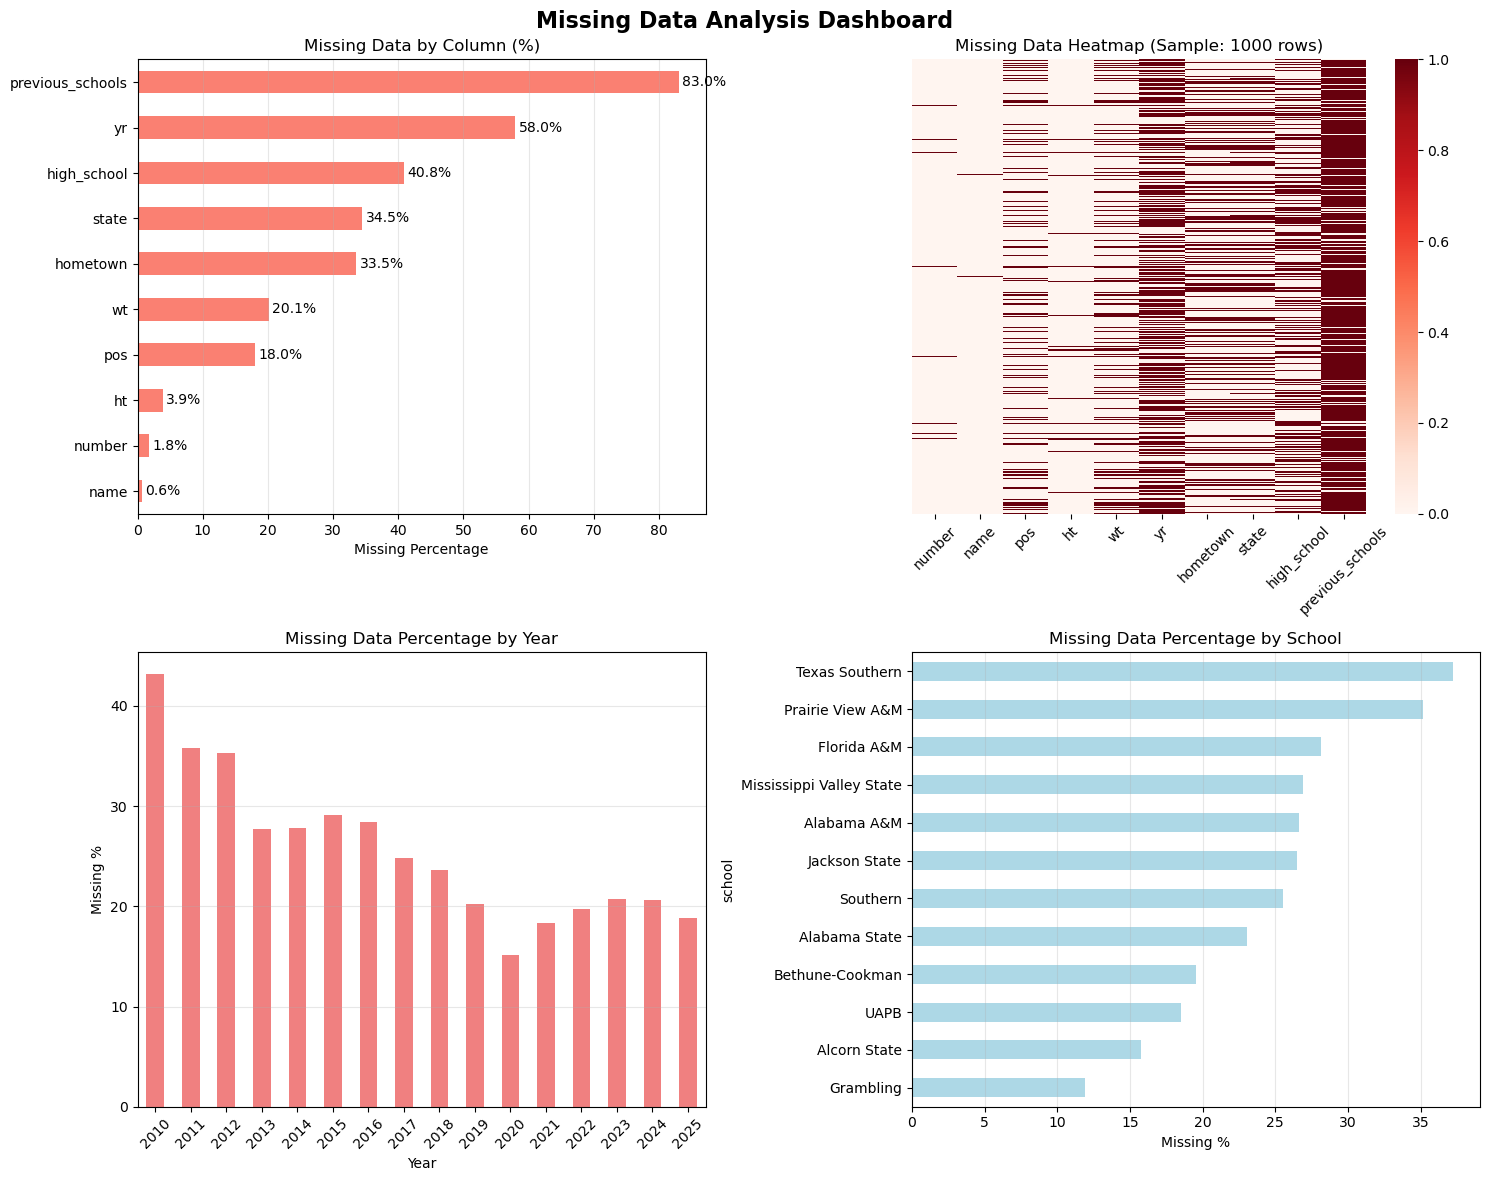


💡 ACTIONABLE INSIGHTS:
   • Overall missing rate: 24.5%
   • Consider removing or imputing: ['previous_schools', 'yr', 'high_school', 'state', 'hometown']
   • Most reliable fields: ['school', 'year']


In [8]:
# ===== MISSING DATA DIAGNOSTICS =====
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_missing_data(df: pd.DataFrame, title: str = "Missing Data Analysis"):
    """Comprehensive missing data analysis for the roster DataFrame."""
    
    if df.empty:
        print("DataFrame is empty - no missing data to analyze.")
        return
    
    print(f"\n{'='*60}")
    print(f"{title}")
    print(f"{'='*60}")
    
    # 1. Basic Info
    print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # 2. Missing counts and percentages
    missing_info = []
    for col in df.columns:
        missing_count = df[col].isna().sum()
        missing_pct = (missing_count / len(df)) * 100
        missing_info.append({
            'Column': col,
            'Missing_Count': missing_count,
            'Missing_Percentage': missing_pct,
            'Data_Type': str(df[col].dtype)
        })
    
    missing_df = pd.DataFrame(missing_info).sort_values('Missing_Percentage', ascending=False)
    
    print(f"\n📊 MISSING DATA SUMMARY:")
    print(missing_df.to_string(index=False, float_format='%.2f'))
    
    # 3. Columns with no missing data
    complete_cols = missing_df[missing_df['Missing_Count'] == 0]['Column'].tolist()
    if complete_cols:
        print(f"\n✅ COMPLETE COLUMNS (no missing data): {len(complete_cols)}")
        print(f"   {complete_cols}")
    
    # 4. Columns with high missingness
    high_missing = missing_df[missing_df['Missing_Percentage'] > 50]
    if not high_missing.empty:
        print(f"\n⚠️  HIGH MISSINGNESS (>50%): {len(high_missing)} columns")
        for _, row in high_missing.iterrows():
            print(f"   • {row['Column']}: {row['Missing_Percentage']:.1f}%")
    
    # 5. Missing patterns by school and year
    if 'school' in df.columns and 'year' in df.columns:
        print(f"\n🏫 MISSING DATA BY SCHOOL:")
        school_missing = df.groupby('school').apply(lambda x: x.isna().sum().sum()).sort_values(ascending=False)
        for school, total_missing in school_missing.head(5).items():
            total_possible = len(df[df['school'] == school]) * df.shape[1]
            pct = (total_missing / total_possible) * 100 if total_possible > 0 else 0
            print(f"   • {school}: {total_missing:,} missing values ({pct:.1f}%)")
        
        print(f"\n📅 MISSING DATA BY YEAR:")
        year_missing = df.groupby('year').apply(lambda x: x.isna().sum().sum()).sort_values(ascending=False)
        for year, total_missing in year_missing.head(5).items():
            total_possible = len(df[df['year'] == year]) * df.shape[1]
            pct = (total_missing / total_possible) * 100 if total_possible > 0 else 0
            print(f"   • {year}: {total_missing:,} missing values ({pct:.1f}%)")
    
    # 6. Rows with complete data
    complete_rows = df.dropna().shape[0]
    complete_pct = (complete_rows / df.shape[0]) * 100
    print(f"\n📋 COMPLETE ROWS: {complete_rows:,} out of {df.shape[0]:,} ({complete_pct:.1f}%)")
    
    # 7. Key field analysis
    key_fields = ['name', 'pos', 'number', 'school', 'year']
    existing_key_fields = [f for f in key_fields if f in df.columns]
    if existing_key_fields:
        print(f"\n🔑 KEY FIELD COMPLETENESS:")
        for field in existing_key_fields:
            complete_count = df[field].notna().sum()
            complete_pct = (complete_count / len(df)) * 100
            print(f"   • {field}: {complete_count:,}/{len(df):,} ({complete_pct:.1f}%) complete")
    
    return missing_df

def create_missing_visualizations(df: pd.DataFrame):
    """Create visualizations for missing data patterns."""
    
    if df.empty:
        print("DataFrame is empty - no visualizations to create.")
        return
    
    # Calculate missing percentages
    missing_pct = (df.isna().sum() / len(df)) * 100
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)
    
    if missing_pct.empty:
        print("🎉 No missing data found - no visualizations needed!")
        return
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Missing Data Analysis Dashboard', fontsize=16, fontweight='bold')
    
    # 1. Missing percentage by column (bar chart)
    if len(missing_pct) > 0:
        ax1 = axes[0, 0]
        missing_pct.plot(kind='barh', ax=ax1, color='salmon')
        ax1.set_title('Missing Data by Column (%)')
        ax1.set_xlabel('Missing Percentage')
        ax1.grid(axis='x', alpha=0.3)
        
        # Add percentage labels
        for i, v in enumerate(missing_pct.values):
            ax1.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    # 2. Missing data heatmap (sample if too large)
    ax2 = axes[0, 1]
    sample_size = min(1000, len(df))  # Sample for performance
    df_sample = df.sample(n=sample_size, random_state=42) if len(df) > sample_size else df
    
    # Only show columns with missing data
    cols_with_missing = df.columns[df.isna().any()].tolist()
    if cols_with_missing:
        missing_matrix = df_sample[cols_with_missing].isna()
        sns.heatmap(missing_matrix, cbar=True, ax=ax2, cmap='Reds', 
                   yticklabels=False, xticklabels=True)
        ax2.set_title(f'Missing Data Heatmap (Sample: {sample_size} rows)')
        ax2.tick_params(axis='x', rotation=45)
    
    # 3. Missing data by year (if year column exists)
    ax3 = axes[1, 0]
    if 'year' in df.columns:
        year_missing = df.groupby('year').apply(lambda x: (x.isna().sum().sum() / (len(x) * x.shape[1])) * 100)
        year_missing.plot(kind='bar', ax=ax3, color='lightcoral')
        ax3.set_title('Missing Data Percentage by Year')
        ax3.set_xlabel('Year')
        ax3.set_ylabel('Missing %')
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'No year column found', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Missing Data by Year (N/A)')
    
    # 4. Missing data by school (if school column exists)
    ax4 = axes[1, 1]
    if 'school' in df.columns:
        school_missing = df.groupby('school').apply(lambda x: (x.isna().sum().sum() / (len(x) * x.shape[1])) * 100)
        school_missing = school_missing.sort_values(ascending=True)
        school_missing.plot(kind='barh', ax=ax4, color='lightblue')
        ax4.set_title('Missing Data Percentage by School')
        ax4.set_xlabel('Missing %')
        ax4.grid(axis='x', alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'No school column found', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Missing Data by School (N/A)')
    
    plt.tight_layout()
    plt.show()

# Run the analysis if master_df exists
if 'master_df' in locals() and not master_df.empty:
    print("🔍 Running comprehensive missing data analysis...")
    
    # Text analysis
    missing_analysis = analyze_missing_data(master_df, "HBCU Football Roster Missing Data Analysis")
    
    # Visual analysis
    print(f"\n📊 Creating missing data visualizations...")
    create_missing_visualizations(master_df)
    
    # Quick actionable summary
    print(f"\n💡 ACTIONABLE INSIGHTS:")
    total_missing = master_df.isna().sum().sum()
    total_possible = master_df.shape[0] * master_df.shape[1]
    overall_missing_pct = (total_missing / total_possible) * 100
    
    print(f"   • Overall missing rate: {overall_missing_pct:.1f}%")
    
    # Most problematic columns
    high_missing_cols = missing_analysis[missing_analysis['Missing_Percentage'] > 25]['Column'].tolist()
    if high_missing_cols:
        print(f"   • Consider removing or imputing: {high_missing_cols}")
    
    # Most complete columns  
    complete_cols = missing_analysis[missing_analysis['Missing_Percentage'] == 0]['Column'].tolist()
    if complete_cols:
        print(f"   • Most reliable fields: {complete_cols[:5]}")  # Show first 5
        
else:
    print("⚠️ No master_df found. Please run the scraper first (cell 6) to generate data.")